In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2025, 11, 1)

df = yf.download(stock, start=start, end=end, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,,
2007-10-05,32.405308,56.587513,61.593765,46.771885,50.512512,855215656
2007-10-08,30.746399,53.690639,58.500015,53.353138,58.500015,126671715
2007-10-09,32.840179,57.346889,57.853138,50.821888,53.718761,116725709
2007-10-10,33.146187,57.881264,59.062515,57.375015,58.837513,67931378
2007-10-11,36.850574,64.350014,67.500015,57.375015,67.500015,106320954


In [4]:
df.shape

(4429, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4429 entries, 2007-10-05 to 2025-09-19
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   (Adj Close, POWERGRID.NS)  4429 non-null   float64
 1   (Close, POWERGRID.NS)      4429 non-null   float64
 2   (High, POWERGRID.NS)       4429 non-null   float64
 3   (Low, POWERGRID.NS)        4429 non-null   float64
 4   (Open, POWERGRID.NS)       4429 non-null   float64
 5   (Volume, POWERGRID.NS)     4429 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 242.2 KB


In [6]:
df.isnull().sum()

Price      Ticker      
Adj Close  POWERGRID.NS    0
Close      POWERGRID.NS    0
High       POWERGRID.NS    0
Low        POWERGRID.NS    0
Open       POWERGRID.NS    0
Volume     POWERGRID.NS    0
dtype: int64

In [7]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4429.000000,4429.000000,4429.000000,4429.000000,4429.000000,4.429000e+03
mean,89.824839,113.721035,115.197737,112.272993,113.783777,1.192003e+07
std,77.427244,72.381856,73.175676,71.573445,72.380406,2.014790e+07
min,18.919926,32.625008,34.875008,29.250008,34.706257,0.000000e+00
25%,36.724586,60.862514,61.706264,60.131264,61.059391,4.927717e+06
50%,66.691895,91.828148,93.375023,90.393768,91.687523,8.528993e+06
75%,100.253662,124.762527,126.534409,123.215652,124.762527,1.377788e+07
max,354.580750,365.450012,366.250000,357.200012,364.049988,8.552157e+08


In [8]:
df = df.reset_index()

In [9]:
df.columns

MultiIndex([(     'Date',             ''),
            ('Adj Close', 'POWERGRID.NS'),
            (    'Close', 'POWERGRID.NS'),
            (     'High', 'POWERGRID.NS'),
            (      'Low', 'POWERGRID.NS'),
            (     'Open', 'POWERGRID.NS'),
            (   'Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [10]:
df.to_csv("powergrid.csv")

In [11]:
data01 = pd.read_csv("powergrid.csv")

In [12]:
data01.head()

,Price,Date,Adj Close,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,32.40530776977539,56.5875129699707,61.59376525878906,46.77188491821289,50.51251220703125,855215656
2,1,2007-10-08,30.74639892578125,53.69063949584961,58.50001525878906,53.3531379699707,58.50001525878906,126671715
3,2,2007-10-09,32.840179443359375,57.34688949584961,57.8531379699707,50.8218879699707,53.7187614440918,116725709
4,3,2007-10-10,33.14618682861328,57.881263732910156,59.06251525878906,57.37501525878906,58.8375129699707,67931378


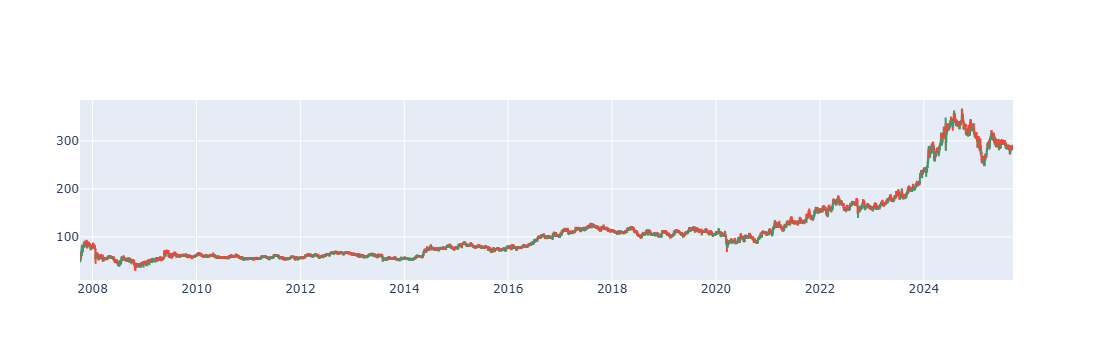

In [13]:
# Candlesticks
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'],
                                     high = data01['High'],
                                     low = data01['Low'],
                                     close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()